Cleaned version of self_rag.ipynb ready for integrating into evaluation.

Changes compared to v2 implementation:
- Switch hallucination grader to open assistant with code interpreter as well
- Add messages list for long-term memory
- Change tonnage and contained metal unit from Mt to tonnes to simplify the problem
- If default value 0 is generated, then go directly to END since no need to check hallucination
    - Assume 0 is always no hallucination (i.e. LLM does not hallucinate no hallucination)
- Changed main validator prompt in VALIDATOR_SYSTEM_PROMPT to set contained metal to zero if tonnage is zero

In [1]:
import json
import re
from collections import Counter
from operator import add
from typing import Annotated, Any, List, Optional

import chromadb
import tiktoken
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain.text_splitter import MarkdownHeaderTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langgraph.graph import END, START, StateGraph
from openai import OpenAI
from pydantic import BaseModel, Field
from typing_extensions import TypedDict

from agent_k.config.logger import logger
from agent_k.config.schemas import (
    TOTAL_MINERAL_RESOURCE_TONNAGE_DESCRIPTION,
)
from agent_k.utils.general import (
    prompt_openai_assistant,
)

load_dotenv()

CLIENT = OpenAI()
NUM_RETRIEVED_DOCS = 5
MODEL = "gpt-4o-mini"


def count_tokens(text):
    try:
        encoding = tiktoken.get_encoding("cl100k_base")
        return len(encoding.encode(text))
    except Exception as e:
        logger.warning(f"Error counting tokens: {e}")
        logger.warning("Falling back to rough approximation (4 tokens per character)")
        return len(text) // 4


def create_markdown_retriever(
    markdown_path: str,
    collection_name: str,
    headers_to_split_on: Optional[list[tuple[str, str]]] = None,
    embedding_model: str = "text-embedding-3-small",
) -> Chroma:
    """
    Creates a Chroma retriever from a markdown document.

    Args:
        markdown_path: Path to the markdown file
        collection_name: Name for the Chroma collection
        headers_to_split_on: List of tuples containing markdown header levels and their names
        embedding_model: Name of the OpenAI embedding model to use

    Returns:
        Chroma retriever object
    """
    # Set default headers if none provided
    if headers_to_split_on is None:
        headers_to_split_on = [
            ("#", "Header 1"),
            ("##", "Header 2"),
            ("###", "Header 3"),
        ]

    # Read markdown file
    try:
        with open(markdown_path, "r", encoding="utf-8") as file:
            markdown_document = file.read()
    except Exception as e:
        logger.error(f"Error reading markdown file: {e}")
        raise

    # Split document
    markdown_splitter = MarkdownHeaderTextSplitter(
        headers_to_split_on=headers_to_split_on
    )
    doc_splits = markdown_splitter.split_text(markdown_document)

    # Log splitting information
    try:
        markdown_document_tokens = count_tokens(markdown_document)
        doc_splits_len = len(doc_splits)
        avg_tokens = markdown_document_tokens / doc_splits_len

        logger.info(f"Number of tokens: {markdown_document_tokens}")
        logger.info(f"Number of splits: {doc_splits_len}")
        logger.info(f"Average tokens per split: {avg_tokens:.0f}")
    except Exception as e:
        logger.warning(f"Could not log token statistics: {e}")

    # Create vectorstore and retriever
    try:
        # Initialize the Chroma client
        client = chromadb.Client()

        # Delete existing in-memory collection if it exists
        try:
            client.delete_collection(collection_name)
            logger.info(f"Deleted existing collection: {collection_name}")
        except Exception:
            pass

        # Create a new vectorstore with persist_directory=None to keep it in-memory
        vectorstore = Chroma.from_documents(
            documents=doc_splits,
            collection_name=collection_name,
            embedding=OpenAIEmbeddings(model=embedding_model),
            persist_directory=None,  # Keep in-memory to avoid persistence
        )

        retriever = vectorstore.as_retriever(search_kwargs={"k": NUM_RETRIEVED_DOCS})
        return retriever
    except Exception as e:
        logger.error(f"Error creating retriever: {e}")
        raise


# Example usage:
retriever = create_markdown_retriever(
    "data/processed/43-101/0200a1c6d2cfafeb485d815d95966961d4c119e8662b8babec74e05b59ba4759d2.md",
    collection_name="rag-chroma",
)

results = retriever.invoke("What's the mineral site name?")
results

2025-03-31 21:14:01.375 | INFO     | __main__:create_markdown_retriever:92 - Number of tokens: 49301
2025-03-31 21:14:01.376 | INFO     | __main__:create_markdown_retriever:93 - Number of splits: 56
2025-03-31 21:14:01.377 | INFO     | __main__:create_markdown_retriever:94 - Average tokens per split: 880


[Document(metadata={'Header 2': 'Table of Contents'}, page_content='| 1                                                                                                                                                                  | SUMMARY AND CONCLUSIONS............................................................................................................ 7                               |\n|--------------------------------------------------------------------------------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------|\n| 2                                                                                                                                                                  | INTRODUCTION AND TERMS OF REFERENCE..............................................................

In [2]:
### Retrieval Grader


class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    reasoning: str = Field(
        description="Reasoning why the document is relevant to the question or not"
    )
    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.1)
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
It does not need to be a stringent test. The goal is to filter out erroneous retrievals. \n
If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""

QUESTION_TEMPLATE = """**Question:** What's the {field} of the mineral site in the attached 43-101 report?
**Data type of {field}:** {dtype}
**Default value of {field} if not found:** {default}
**Description of {field}:** {description}"""

grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "# Retrieved document\n{document}\n\n# User question\n{question}"),
    ]
)

template = "# Retrieved document\n{document}\n\n# User question\n{question}"
# print(template.format(document="[sample document]", question="[sample question]"))

retrieval_grader = grade_prompt | structured_llm_grader

In [3]:
### Generate

# Deep Extraction Assistant (Sync with OpenAI Assistant)
DEEP_EXTRACT_SYSTEM_PROMPT = """You are an advanced AI assistant that answers questions based on the attached NI 43-101 mineral report. Your responses should be grounded in the report's content using the code interpreter tool for numerical calculations.

## Response Workflow:
1. Perform Aggregations: Use the code interpreter tool for operations like summation, multiplication, or other numerical operations.
2. Structure the Response Correctly: Format your final output with XML tags as follows:
    - Reasoning: Explain your retrieval or computation process within `<thinking>` tags.
    - Final Answer: Provide the final response within `<output>` tags. Do not include other extra XML tags (e.g., `<answer>`) or filler words.

## Key Constraints:
- No Hallucination: If the required information is unavailable, return the default value specified in the JSON schema in the `<output>` tag.
"""

GENERATION_USER_PROMPT_WO_FEEDBACK = """You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just return the default value of the field in the question.

{question}
**Context:** {context} 
---
Now take a deep breath and answer the question step by step."""

GENERATION_USER_PROMPT_W_FEEDBACK = """You are an assistant for question-answering tasks. Use the following pieces of retrieved context and previous feedback on incorrect answers to answer the question. If you don't know the answer, just return the default value of the field in the question.

{question}
**Context:** {context} 
**Previous answers and feedback:** {previous_messages}
---
Now take a deep breath and answer the question again step by step while considering the feedback to the previous incorrect answer."""


### Alternative RAG chain using OpenAI Assistant


# OpenAI Assistant with code interpreter tool
# @traceable(run_type="llm", name="deep_extract_wo_feedback")
def deep_extract_wo_feedback(question, context) -> str:
    # Use the same assistant for all deep extraction
    assistant = CLIENT.beta.assistants.retrieve("asst_ScLkkCGSfMVgR8xEWkRDbZMq")

    messages = [
        {
            "role": "user",
            "content": GENERATION_USER_PROMPT_WO_FEEDBACK.format(
                question=question,
                context=context,
            ),
        },
    ]

    content = prompt_openai_assistant(assistant, messages)

    return content


# @traceable(run_type="llm", name="deep_extract_w_feedback")
def deep_extract_w_feedback(question, context, previous_messages) -> str:
    # Use the same assistant for all deep extraction
    assistant = CLIENT.beta.assistants.retrieve("asst_ScLkkCGSfMVgR8xEWkRDbZMq")

    # Convert previous messages to a list of strings from a list of dicts
    previous_messages_str = [str(msg) for msg in previous_messages]

    messages = [
        {
            "role": "user",
            "content": GENERATION_USER_PROMPT_W_FEEDBACK.format(
                question=question,
                context=context,
                previous_messages="\n".join(previous_messages_str),
            ),
        },
    ]

    content = prompt_openai_assistant(assistant, messages)

    return content

In [4]:
### Hallucination Grader

# Data model
class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    feedback: str = Field(
        description="Reasoning whether the raw facts in the answer are aligned with the retrieved documents + feedback on how to improve"
    )
    binary_score: str = Field(
        description="Raw facts in the answer are aligned with the retrieved documents, 'yes' or 'no'"
    )


json_schema = GradeHallucinations.model_json_schema()
json_schema_str = json.dumps(json_schema)
print(json_schema_str)


# generate json schema for GradeHallucinations (Update in OpenAI Assistant)
json_schema = GradeHallucinations.model_json_schema()

# OpenAI Assistant JSON Schema
json_schema_openai_standard = {
    "name": "GradeHallucinations",
    "strict": True,
    "schema": {
        "type": "object",
        "properties": {
            "feedback": {
                "type": "string",
                "description": "Reasoning whether the raw facts in the answer are aligned with the retrieved documents + feedback on how to improve",
            },
            "binary_score": {
                "type": "string",
                "description": "Raw facts in the answer are aligned with the retrieved documents, 'yes' or 'no'.",
            },
        },
        "required": ["feedback", "binary_score"],
        "additionalProperties": False,
    },
}


# LLM with function call
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.1)
structured_llm_grader = llm.with_structured_output(GradeHallucinations)

# Prompt (Update in OpenAI Assistant)
system = """You are a hallucination agent validating whether a LLM's generation is consistent with the retrieved documents from a NI 43-101 mineral report. Focus on the calculation logic and unit conversions.

Guidelines:
1. Check if total mineral resource tonnage is the sum of inferred, indicated, and measured mineral resources. If not, a default value of 0 should be returned.
2. Check if total mineral reserve tonnage is the sum of proven and probable mineral reserves. If not, a default value of 0 should be returned.
3. Check if the tonnage or grade unit used in the LLM generation is consistent with the unit used in the retrieved documents. For example, "Tonnes 000", "Tonnes (000)", or "(000) Tonnes" mean thousand tonnes (Kt) or 1000 tonnes (t).
4. Check if the unit of final answer enclosed in `<output>` tags is converted correctly to tonnes (t).

Show your feedback and give a binary score 'yes' or 'no' and . 'Yes' means that the LLM generation is consistent with the retrieved documents and no hallucination."""

user_prompt_template = """# Retrieved Documents
{documents}

# LLM Generation
{generation}

# Previous Messages
{previous_messages}

___
Now take a deep breath and grade the LLM generation based on the retrieved documents and previous messages between you and the LLM generator."""

hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", user_prompt_template),
    ]
)

# print(user_prompt_template.format(documents="[sample documents]", generation="[sample generation]"))

hallucination_grader = hallucination_prompt | structured_llm_grader


def hallucination_grader_assistant(
    documents, generation, previous_messages
) -> GradeHallucinations:
    # Use openai assistant to grade the generation
    assistant = CLIENT.beta.assistants.retrieve("asst_pgJ1WkxCaHeCcShpdIMIFl6C")

    # Convert previous messages to a list of strings from a list of dicts
    previous_messages_str = [str(msg) for msg in previous_messages]

    messages = [
        {
            "role": "user",
            "content": user_prompt_template.format(
                documents=documents,
                generation=generation,
                previous_messages="\n".join(previous_messages_str),
            ),
        },
    ]
    content = prompt_openai_assistant(assistant, messages)

    content_structured = GradeHallucinations.model_validate_json(content)

    return content_structured

{"description": "Binary score for hallucination present in generation answer.", "properties": {"feedback": {"description": "Reasoning whether the raw facts in the answer are aligned with the retrieved documents + feedback on how to improve", "title": "Feedback", "type": "string"}, "binary_score": {"description": "Raw facts in the answer are aligned with the retrieved documents, 'yes' or 'no'", "title": "Binary Score", "type": "string"}}, "required": ["feedback", "binary_score"], "title": "GradeHallucinations", "type": "object"}


In [5]:
### Answer Grader

# Data model
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    reasoning: str = Field(
        description="Reasoning if the answer addresses the question or not"
    )
    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.1)
structured_llm_grader = llm.with_structured_output(GradeAnswer)

# Prompt
system = """You are a grader assessing whether an answer addresses / resolves a question.

Guidelines:
1. Check if the reasoning is enclosed in `<thinking>` XML tags.
2. Check if the final numerical answer is enclosed in `<output>` XML tags without any other XML tags, filler words, or explicit unit.
3. A default value 0 also counts as an invalid answer.

Give a binary score 'yes' or 'no'. Yes' means that the answer resolves the question."""
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "# Question\n{question}\n\n# LLM Generation\n{generation}"),
    ]
)

answer_grader = answer_prompt | structured_llm_grader

In [6]:
### Question Re-writer

# LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.1)

# Prompt
system = """You a question re-writer that converts an input question to a better version that is optimized for vectorstore retrieval. Look at the input and try to reason about the underlying semantic intent / meaning."""
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question:\n\n---\n{question}\n--- \n\nFormulate an improved question.",
        ),
    ]
)

template = "Here is the initial question:\n\n---\n{question}\n--- \n\nFormulate an improved question."
# print(template.format(question="[sample question]"))

question_rewriter = re_write_prompt | llm | StrOutputParser()

# Graph

In [7]:
class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        documents: list of documents
    """

    question: str
    generation: str
    documents: List[str]

    # Added by Yixin
    retriever: Any
    hallucination_grade: str
    answer_grade: str
    messages: Annotated[list[str], add]  # store prev generation + feedback
    answers: Annotated[list[str], add]  # store prev ans for self consistency

In [8]:
### Nodes


def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    logger.info("---RETRIEVE---")
    question = state["question"]

    # Retrieval
    documents = state["retriever"].invoke(question)

    return {"documents": documents}


def get_mode_or_last(lst):
    count = Counter(lst)
    max_count = max(count.values())

    # Check if the mode is unique
    modes = [item for item, cnt in count.items() if cnt == max_count]

    if max_count > 1 and len(modes) == 1:
        return modes[0]
    else:
        return lst[-1]


def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    logger.info("---GENERATE---")
    question = state["question"]
    documents = state["documents"]
    hallucination_grade = state["hallucination_grade"]
    answer_grade = state["answer_grade"]

    if len(state["answers"]) >= 3:
        # Self consistency if detected looping
        mode_answer = get_mode_or_last(state["answers"])
        generation = f"<reasoning>Detect looping. Use self consistency to choose the most popular answer from previous generations.</reasoning><output>{mode_answer}</output>"
    elif hallucination_grade.lower() == "no" or answer_grade.lower() == "no":
        # RAG generation with previous generation and feedback
        previous_messages = state["messages"]
        generation = deep_extract_w_feedback(question, documents, previous_messages)
    else:
        # Initial RAG generation without hallucination grader feedback
        generation = deep_extract_wo_feedback(question, documents)

    try:
        parsed_output = generation.split("<output>")[1].split("</output>")[0].strip()
        parsed_output = re.sub(r"[^0-9.]", "", parsed_output)
    except IndexError:
        logger.exception(f"Error parsing <output> XML tags for content: {generation}")

    return {
        "generation": generation,
        "answers": [parsed_output],
        "messages": [
            {"role": "Answer generator", "content": generation},
        ],
    }


def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    logger.info("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            logger.info("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            logger.info("---GRADE: DOCUMENT NOT RELEVANT---")
            continue

    return {"documents": filtered_docs}


def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    logger.info("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}


def check_hallucination(state):
    """
    First node: Check if generation is grounded in documents.

    Args:
        state (dict): The current graph state
    Returns:
        dict: State updates and next node
    """
    logger.info("---CHECK HALLUCINATIONS---")
    documents = state["documents"]
    generation = state["generation"]
    previous_messages = state["messages"]

    score = hallucination_grader_assistant(documents, generation, previous_messages)
    grade = score.binary_score
    hallucination_grader_feedback = score.feedback
    return {
        "hallucination_grade": grade,
        "messages": [
            {
                "role": "Hallucination grader",
                "content": f"No hallucination: {grade}, Feedback: {hallucination_grader_feedback}",
            }
        ],
    }


def check_answers_question(state):
    """
    Second node: Check if generation answers the question.

    Args:
        state (dict): The current graph state
    Returns:
        dict: State updates and next node
    """
    logger.info("---GRADE GENERATION vs QUESTION---")
    question = state["question"]
    generation = state["generation"]

    score = answer_grader.invoke({"question": question, "generation": generation})
    grade = score.binary_score
    answer_grader_reasoning = score.reasoning

    return {
        "answer_grade": grade,
        "messages": [
            {
                "role": "Answer grader",
                "content": f"Answer addresses question: {grade}, Reasoning: {answer_grader_reasoning}",
            }
        ],
    }


### Edges


def retriever_router(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    logger.info("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    filtered_documents = state["documents"]

    if not filtered_documents:
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        logger.info(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        logger.info("---DECISION: GENERATE---")
        return "generate"


def generate_router(state):
    # Use regex to check if the generation matches the pattern "<output>X</output>"
    # where X is a number (integer or decimal)
    generation: str = state["generation"]
    output_pattern = re.compile(r"<output>(\d+(?:\.\d+)?)</output>")
    match = output_pattern.search(generation)

    # Extract the numeric value from the match and convert it to a number
    answer = None
    if match:
        numeric_string = match.group(1)
        try:
            answer = float(numeric_string)
        except ValueError:
            logger.warning(
                f"---FAILED TO CONVERT MATCHED STRING TO NUMBER: {numeric_string}---"
            )

    if "self consistency" in generation:
        logger.info("---DECISION: LOOPING DETECT. USE SELF CONSISTENCY VALUE. END---")
        return END
    elif answer != 0:
        logger.info(
            "---DECISION: GENERATION CONTAINS NUMERIC OUTPUT, CHECK HALLUCINATION---"
        )
        return "check_hallucination"
    elif answer == 0:
        logger.info("---DECISION: GENERATION RETURNS DEFAULT VALUE 0. END---")
        return END


def hallucination_router(state):
    """
    Route based on hallucination check result
    """
    if state["hallucination_grade"].lower() == "yes":
        logger.info(
            "---DECISION: GENERATION IS GROUNDED IN DOCUMENTS (NO HALLUCINATION)---"
        )
        return "check_answers_question"
    else:
        logger.info(
            "---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY (HALLUCINATION)---"
        )
        return "regenerate"


def answer_quality_router(state):
    """
    Route based on answer quality check result
    """
    if state["answer_grade"] == "yes":
        logger.info("---DECISION: GENERATION ADDRESSES QUESTION---")
        return "useful"
    else:
        logger.info("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
        return "regenerate"

## Build Graph


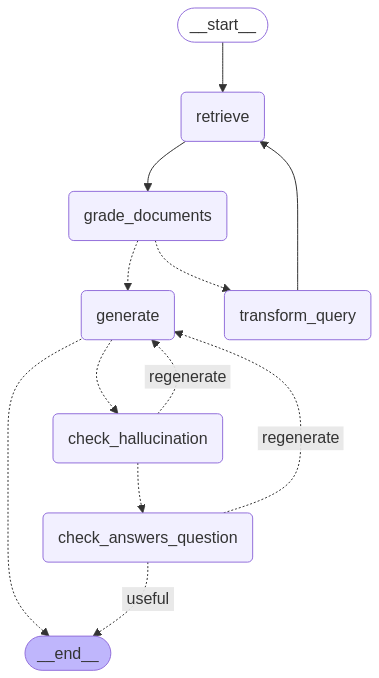

In [9]:
def viz_graph(graph):
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception:
        pass


self_rag_graph_builder = StateGraph(GraphState)

# Define the nodes
self_rag_graph_builder.add_node("retrieve", retrieve)  # retrieve
self_rag_graph_builder.add_node("grade_documents", grade_documents)  # grade documents
self_rag_graph_builder.add_node("generate", generate)  # generatae
self_rag_graph_builder.add_node("transform_query", transform_query)  # transform_query
self_rag_graph_builder.add_node(
    "check_hallucination", check_hallucination
)  # check hallucination
self_rag_graph_builder.add_node(
    "check_answers_question", check_answers_question
)  # check answers question

# Build graph
self_rag_graph_builder.add_edge(START, "retrieve")
self_rag_graph_builder.add_edge("retrieve", "grade_documents")
self_rag_graph_builder.add_conditional_edges(
    "grade_documents",
    retriever_router,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
# self_rag_graph_builder.add_edge("generate", "check_hallucination")
self_rag_graph_builder.add_conditional_edges(
    "generate",
    generate_router,
    {"check_hallucination": "check_hallucination", END: END},
)
self_rag_graph_builder.add_edge("transform_query", "retrieve")
self_rag_graph_builder.add_conditional_edges(
    "check_hallucination",
    hallucination_router,
    {
        "check_answers_question": "check_answers_question",
        "regenerate": "generate",
    },
)
self_rag_graph_builder.add_conditional_edges(
    "check_answers_question",
    answer_quality_router,
    {
        "useful": END,
        "regenerate": "generate",
    },
)

# Compile
self_rag_graph = self_rag_graph_builder.compile()

# Visualize the graph
viz_graph(self_rag_graph)

In [10]:
# Run
if __name__ == "__main__":
    question = QUESTION_TEMPLATE.format(
        field="total_mineral_resource_tonnage",
        # field="total_mineral_reserve_contained_metal",
        dtype="float",
        default=0,
        description=TOTAL_MINERAL_RESOURCE_TONNAGE_DESCRIPTION,
        # description=TOTAL_MINERAL_RESERVE_CONTAINED_METAL_DESCRIPTION.replace(
        #     "<main_commodity>", "nickel"
        # ),
    )

    retriever = create_markdown_retriever(
        "data/processed/43-101/0200a1c6d2cfafeb485d815d95966961d4c119e8662b8babec74e05b59ba4759d2.md",
        collection_name="rag-chroma",
    )

    inputs = {
        "question": question,
        "generation": "N/A",
        "retriever": retriever,
        "hallucination_grade": "N/A",
        "answer_grade": "N/A",
    }

    value = self_rag_graph.invoke(inputs, config={"recursion_limit": 10})

    # Final generation
    logger.info("---FINAL GENERATION---")
    logger.info(value["generation"])

2025-03-31 21:14:04.948 | INFO     | __main__:create_markdown_retriever:92 - Number of tokens: 49301
2025-03-31 21:14:04.949 | INFO     | __main__:create_markdown_retriever:93 - Number of splits: 56
2025-03-31 21:14:04.950 | INFO     | __main__:create_markdown_retriever:94 - Average tokens per split: 880
2025-03-31 21:14:04.953 | INFO     | __main__:create_markdown_retriever:106 - Deleted existing collection: rag-chroma
2025-03-31 21:14:06.433 | INFO     | __main__:retrieve:14 - ---RETRIEVE---
2025-03-31 21:14:06.754 | INFO     | __main__:grade_documents:90 - ---CHECK DOCUMENT RELEVANCE TO QUESTION---
2025-03-31 21:14:13.481 | INFO     | __main__:grade_documents:105 - ---GRADE: DOCUMENT NOT RELEVANT---
2025-03-31 21:14:14.724 | INFO     | __main__:grade_documents:102 - ---GRADE: DOCUMENT RELEVANT---
2025-03-31 21:14:16.241 | INFO     | __main__:grade_documents:102 - ---GRADE: DOCUMENT RELEVANT---
2025-03-31 21:14:18.169 | INFO     | __main__:grade_documents:105 - ---GRADE: DOCUMENT NOT